# Sistema de predicción de ventas.

In [463]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import numpy as np
import pickle
import pmdarima as pm


## Definición del problema.

En este caso, trabajo con un conjunto de datos de ventas, y el objetivo será estimar el ritmo de las ventas desde la creación de la empresa para los próximos meses, a fin de proveer el espacio que se necesitará para su nueva localización.

> "¿Cuál será el volumen total de ventas para los siguientes meses en el periodo de tiempo de la mudanza y posterior?".


## Recopilación de datos.

In [464]:
df = pd.read_csv("../data/raw/sales.csv")

## Análisis Descriptivo.

In [465]:
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [466]:
df.dtypes

date      object
sales    float64
dtype: object

#### Observaciones: 
> - El conjunto de datos esta compuesto por 366 filas y dos columnas.
> - Columna `date` es de tipo objeto.
> - columna `sales` es de tipo flotante.

## Limpieza de Datos.

In [467]:
df.duplicated().sum()

np.int64(0)

In [468]:
df.isnull().sum()

date     0
sales    0
dtype: int64

In [469]:
df.nunique()

date     366
sales    366
dtype: int64

In [470]:
#Se modifico el tipo de dato.
df['date'] = pd.to_datetime(df['date'])

In [471]:
df.dtypes

date     datetime64[ns]
sales           float64
dtype: object

#### Observaciones:
> - No hay duplicados.
> - No hay valores nulos.
> - El conjunto de datos esta establecido en el periodo de un año.
> - La variable `date` ha sido modificado a dtypes=datetime64

In [472]:
#para asegurarse que el dataframe esta ordenado cronologicamente.
df = df.sort_index()

Se establece `date` como índice del DataFrame.

In [473]:
df = df.set_index("date")
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


> - Se observa que la entrada de los datos se realiza todos los días a la misma hora.

Para el índice elimino las horas y dejo la fecha.

In [474]:
df.index = df.index.normalize()
df.head()

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


#### Observaciones:
> - Dimensión temporal: año, mes y día.
> - El dato que se observa a lo largo del tiempo es el número de ventas (sales).

### Visualización de la serie temporal.

In [475]:
ts = df['sales']

### Descomposición de la serie temporal.

In [476]:
#Descomposición semanal, estacionalidad.
decomposition = seasonal_decompose(ts, period=7)

#Componente estacionario.
seasonal = decomposition.seasonal

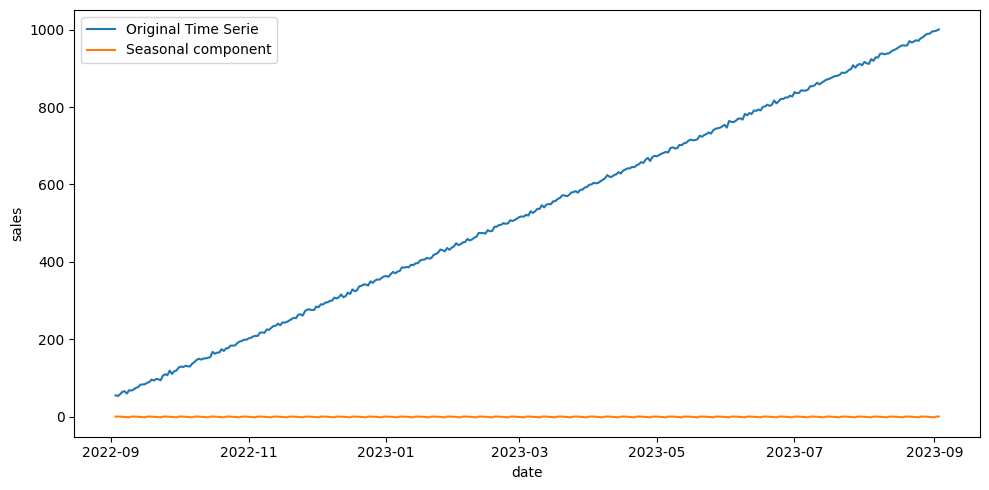

In [477]:
fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(data=ts, label="Original Time Serie")
sns.lineplot(data=seasonal, label="Seasonal component")

plt.tight_layout()

#### Observaciones:


> Serie temporal:
> - Tensor: El tensor de la serie temporal es **diaria**, la unidad de tiempo mínima para la cual hay datos.
> - Tendencia: **ascendente**, muestra un crecimiento constante a largo plazo.
> - Estacionalidad:  **no es estacionaria**, el crecimiento aparece siempre constante sin depender de un periodo.
> - Variabilidad: hay **pequeñas fluctuaciones diarias** por encima y por debajo de la línea de tendencia, sin cambios bruscos.
> - Ruidos: **No** presenta ruidos.


Prueba de estacionariedad.

In [478]:
def test_stationarity(timeseries):
    df_test = adfuller(timeseries, autolag="AIC")
    df_output = pd.Series(df_test[0:4], index=["Test Statistic", "p-value", "Lags Used", "Number of Observations Used"])
    for key, value in df_test[4].items():
        df_output[f'Critical Value {key}'] = value
    return df_output

In [479]:
test_stationarity(ts)

Test Statistic                   0.545414
p-value                          0.986190
Lags Used                       13.000000
Number of Observations Used    352.000000
Critical Value 1%               -3.449065
Critical Value 5%               -2.869786
Critical Value 10%              -2.571163
dtype: float64

#### Observaciones:
> - El valor de p-value superior a 0.05 indica que la serie temporal **no es estacionaria.**

### Modelo ARIMA.

Para optimizar al máximo sus resultados, debemos transformar la serie en estacionaria, y como en el caso de esta serie no lo es, debemos transformarla:

In [480]:
ts_stationary = ts.diff().dropna()
ts_stationary

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Freq: D, Name: sales, Length: 365, dtype: float64

Comparación de la serie inicial a su conversión como serie estacionaria.

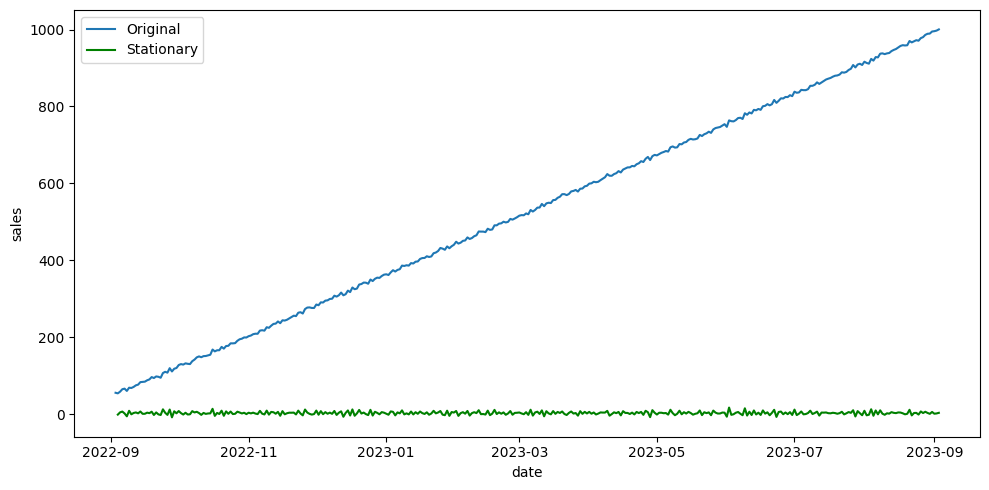

In [481]:
plt.figure(figsize=(10,5))
sns.lineplot(data=ts, label="Original")
sns.lineplot(data=ts_stationary, color="green", label="Stationary")

plt.legend()
plt.tight_layout()

Prueba de la Estacionariedad de la serie temporal

In [482]:
resultado_adf = adfuller(ts_stationary)
resultado_adf

(np.float64(-9.430263118334729),
 np.float64(5.212954111417404e-16),
 12,
 352,
 {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)},
 np.float64(1758.277879882476))

**Ahora que la serie es estacionaria , p-value=5.2e-16 podemos aplicar el método ARIMA automático:**

`auto_arima`: Se encarga automáticamente de buscar los mejores parámetros para el modelo ARIMA.

In [483]:
ts_stationary

date
2022-09-04   -1.488946
2022-09-05    4.338482
2022-09-06    6.389205
2022-09-07    1.482734
2022-09-08   -5.931768
                ...   
2023-08-30    0.518681
2023-08-31    5.386972
2023-09-01    0.827090
2023-09-02    1.535798
2023-09-03    3.132571
Freq: D, Name: sales, Length: 365, dtype: float64

In [484]:
ts_stationary = ts.diff().dropna()

In [485]:
# 1. Definir el tamaño o fecha de corte
train_size = int(len(ts) * 0.8)

# 2. Serie Original (Escala real - la que usas para last_train_value)
ts_train_orig = ts.iloc[:train_size]
ts_test_orig = ts.iloc[train_size:]

# El split de la estacionaria debe alinearse con el de la original
train = ts_stationary.iloc[:train_size-1] # -1 porque diff() eliminó el primer registro
test = ts_stationary.iloc[train_size-1:]

In [486]:
model = pm.auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, d=0, error_action='ignore')

n_periods = len(test)
predictions = model.predict(n_periods=n_periods)

last_train_value = ts_train_orig.iloc[-1]
forecast_original_scale = predictions.cumsum() + last_train_value

In [487]:
#Informe estadistico
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  291
Model:               SARIMAX(1, 0, 3)   Log Likelihood                -739.855
Date:                Mon, 05 Jan 2026   AIC                           1489.710
Time:                        18:28:49   BIC                           1508.077
Sample:                    09-04-2022   HQIC                          1497.068
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   5.63e-06   1.78e+05      0.000       1.000       1.000
ma.L1         -1.9961      0.057    -35.308      0.000      -2.107      -1.885
ma.L2          1.0777      0.108      9.975      0.000       0.866       1.289
ma.L3         -0.0808      0.055     -1.469      0.142      -0.188       0.027
sigma2         9.1444      0.843     10.845      0.000       7.492      10.797
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 2.08
Prob(Q):                              0.84   Prob(JB):                         0.35
Heteroskedasticity (H):               0.94   Skew:                             0.06
Prob(H) (two-sided):                  0.77   Kurtosis:                         2.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Re-entrenamiento del Modelo con el conjunto de entrenamiento y la mejor parametrización.

In [488]:
#Usamos la clase ARIMA directamente: Define la estructura del modelo.
model_test = ARIMA(train, order=(1, 0, 3), seasonal_order=(1, 0, 3, 7))

#Ajustar el modelo: Entrena el modelo.
results = model_test.fit()

results.summary() 

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                    
=======================================================================================
Dep. Variable:                           sales   No. Observations:                  291
Model:             ARIMA(1, 0, 3)x(1, 0, 3, 7)   Log Likelihood                -727.755
Date:                         Mon, 05 Jan 2026   AIC                           1475.510
Time:                                 18:28:51   BIC                           1512.244
Sample:                             09-04-2022   HQIC                          1490.226
                                  - 06-21-2023                                         
Covariance Type:                           opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5995      0.005    550.816      0.000       2.590       2.609
ar.L1         -0.2018      0.887     -0.228      0.820      -1.940       1.536
ma.L1         -0.8472      0.883     -0.959      0.337      -2.578       0.884
ma.L2         -0.0786      0.938     -0.084      0.933      -1.918       1.760
ma.L3         -0.0538      0.094     -0.571      0.568      -0.239       0.131
ar.S.L7       -0.8486      0.153     -5.555      0.000      -1.148      -0.549
ma.S.L7        1.0297      0.167      6.165      0.000       0.702       1.357
ma.S.L14       0.2300      0.098      2.355      0.019       0.039       0.421
ma.S.L21      -0.0040      0.081     -0.049      0.961      -0.163       0.155
sigma2         8.5857      0.816     10.523      0.000       6.987      10.185
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.98   Prob(JB):                         0.50
Heteroskedasticity (H):               0.90   Skew:                             0.08
Prob(H) (two-sided):                  0.61   Kurtosis:                         2.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [489]:
# Predecir sobre el set de test
forecast_diff = results.forecast(steps=len(test))

# Revertir la diferenciación (Tu fórmula maestra)
last_train_value = ts_train_orig.iloc[-1]
forecast_final = forecast_diff.cumsum() + last_train_value

#### Revertimos la diferenciación para predecir en la serie original.

In [ ]:
# Escala Original (Lo que le interesa al negocio)
actual_real = ts_test_orig.values
predicted_real = forecast_final.values

# Asegúrate de que tengan la misma longitud
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actual_real, predicted_real)
mse = mean_squared_error(actual_real, predicted_real)
rmse = np.sqrt(mse)

print(f"Error medio en ventas reales: {mae:.2f}")

Error medio en ventas reales: 2.17


In [ ]:
metrics = {'MSE': mean_squared_error(actual_real, predicted_real),
           'RMSE': root_mean_squared_error(actual_real, predicted_real),
           'MAPE' : mean_absolute_percentage_error(actual_real, predicted_real),
           'R^2': r2_score(actual_real, predicted_real)}

metrics

{'MSE': 7.384290464540942,
 'RMSE': 2.7174050976144395,
 'MAPE': 0.0024065095697378643,
 'R^2': 0.9976026989941412}

##### Observaciones:
> - MAPE:la predicción casi no se desvio de la venta real.
> - R²: indica que el modelo explica el 99% de la variabilidad total en los datos de prueba.

### Visualización del pronostico final:

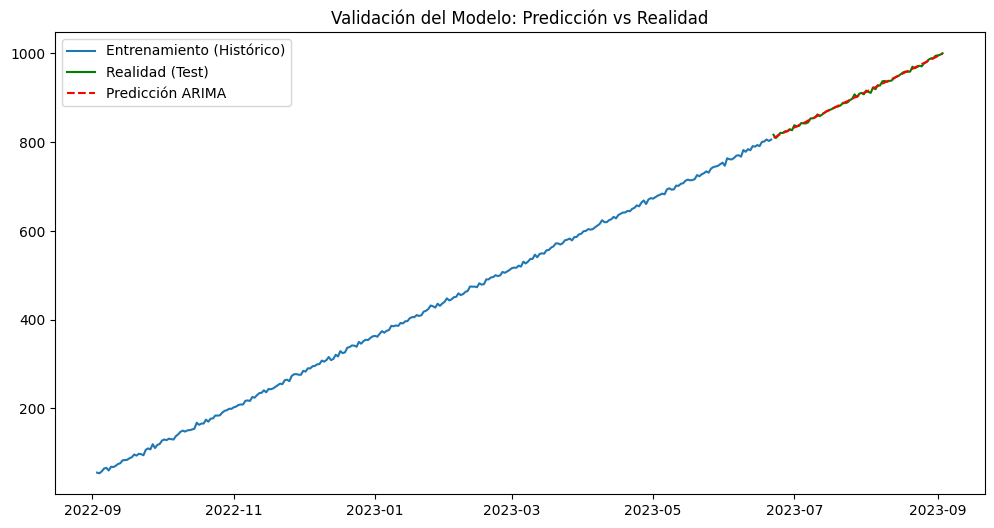

In [493]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ts_train_orig.index, ts_train_orig, label='Entrenamiento (Histórico)')
plt.plot(ts_test_orig.index, ts_test_orig, label='Realidad (Test)', color='green')
plt.plot(ts_test_orig.index, forecast_final, label='Predicción ARIMA', color='red', linestyle='--')
plt.title('Validación del Modelo: Predicción vs Realidad')
plt.legend()
plt.show()

> "¿Cuál será el volumen total de ventas para los siguientes meses en el periodo de tiempo de la mudanza y posterior?".
> - **Se espera que las ventas sigan alcistas con un crecimiento constante como hasta ahora.**

### Guardar Modelo.

In [ ]:
with open('../models/time_series_forecasting_sales.pkl', 'wb') as file:
    pickle.dump(model_test, file)

### Conclusiones
> - El modelo ha identificado correctamente la fuerte tendencia alcista de las ventas.